In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df=pd.read_csv("/content/war_economic_impact_dataset.csv")
print(df)

          Conflict_Name                  Conflict_Type       Region  \
0          WWII (Japan)                      World War    East Asia   
1      Israel-Hamas War                 Asymmetric War  Middle East   
2      Syrian Civil War                      Civil War  Middle East   
3        WWII (Germany)                      World War       Europe   
4       Afghanistan War  Interstate/Counter-insurgency   South Asia   
...                 ...                            ...          ...   
99995   Afghanistan War  Interstate/Counter-insurgency   South Asia   
99996   Israel-Iran War                 Interstate War  Middle East   
99997   Israel-Iran War                 Interstate War  Middle East   
99998  Israel-Hamas War                 Asymmetric War  Middle East   
99999   Tigray Conflict                      Civil War       Africa   

       Start_Year  End_Year    Status   Primary_Country  \
0            1939      1945  Resolved             Japan   
1            2023      2026  

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   Conflict_Name                            100000 non-null  object 
 1   Conflict_Type                            100000 non-null  object 
 2   Region                                   100000 non-null  object 
 3   Start_Year                               100000 non-null  int64  
 4   End_Year                                 100000 non-null  int64  
 5   Status                                   100000 non-null  object 
 6   Primary_Country                          100000 non-null  object 
 7   Pre_War_Unemployment_%                   100000 non-null  float64
 8   During_War_Unemployment_%                100000 non-null  float64
 9   Unemployment_Spike_Percentage_Points     100000 non-null  float64
 10  Most_Affected_Sector             

In [32]:
df.shape

(100000, 28)

In [33]:
df.head()

,Conflict_Name,Conflict_Type,Region,Start_Year,End_Year,Status,Primary_Country,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,...,Inflation_Rate_%,Currency_Devaluation_%,Cost_of_War_USD,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Black_Market_Activity_Level,Primary_Black_Market_Goods,Currency_Black_Market_Rate_Gap_%,War_Profiteering_Documented
0,WWII (Japan),World War,East Asia,1939,1945,Resolved,Japan,7.49,21.78,14.29,...,97.41,170.33,106957216228,209054555175,15.50,27.09,High,food,10.50,No
1,Israel-Hamas War,Asymmetric War,Middle East,2023,2026,Ongoing,Palestine (Gaza),8.18,23.00,14.82,...,73.68,41.97,304164881098,585915946162,11.95,34.76,Dominant,fuel,19.31,No
2,Syrian Civil War,Civil War,Middle East,2011,2026,Ongoing,Syria,12.70,36.46,23.76,...,69.35,53.91,484822729254,1666739121273,38.18,90.00,Moderate,"water, weapons, currency",298.95,No
3,WWII (Germany),World War,Europe,1939,1945,Resolved,Germany,14.06,17.83,3.77,...,36.92,48.51,71321188262,250015887113,12.24,36.42,Moderate,"currency, medicine, weapons",15.44,No
4,Afghanistan War,Interstate/Counter-insurgency,South Asia,2001,2021,Resolved,Afghanistan,5.38,5.98,0.59,...,52.62,31.32,156180178536,361238241031,31.89,74.86,Dominant,medicine,443.61,Yes


In [34]:
df.tail()

,Conflict_Name,Conflict_Type,Region,Start_Year,End_Year,Status,Primary_Country,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,...,Inflation_Rate_%,Currency_Devaluation_%,Cost_of_War_USD,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Black_Market_Activity_Level,Primary_Black_Market_Goods,Currency_Black_Market_Rate_Gap_%,War_Profiteering_Documented
99995,Afghanistan War,Interstate/Counter-insurgency,South Asia,2001,2021,Resolved,Afghanistan,4.76,6.39,1.64,...,17.59,15.01,253739029093,962895329018,24.29,38.53,Dominant,"currency, water, weapons",0.16,Yes
99996,Israel-Iran War,Interstate War,Middle East,2025,2026,Ongoing,Iran,6.31,9.18,2.88,...,29.05,40.53,442499418502,812364353669,23.63,52.81,Low,"weapons, currency",341.19,No
99997,Israel-Iran War,Interstate War,Middle East,2025,2026,Ongoing,Iran,9.21,24.93,15.71,...,44.44,88.01,80743472895,192543974304,28.69,60.65,Low,"food, weapons, fuel",139.88,Yes
99998,Israel-Hamas War,Asymmetric War,Middle East,2023,2026,Ongoing,Palestine (Gaza),7.67,13.25,5.58,...,17.16,12.25,310021533648,1123347785558,22.96,47.43,Dominant,"water, medicine, weapons",18.20,Yes
99999,Tigray Conflict,Civil War,Africa,2020,2022,Resolved,Ethiopia,5.70,16.04,10.34,...,96.06,128.06,149842127082,255216818919,25.48,44.35,High,"currency, medicine",5.59,No


In [35]:
df.describe()

,Start_Year,End_Year,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,Youth_Unemployment_Change_%,Pre_War_Poverty_Rate_%,During_War_Poverty_Rate_%,Extreme_Poverty_Rate_%,Food_Insecurity_Rate_%,Households_Fallen_Into_Poverty_Estimate,GDP_Change_%,Inflation_Rate_%,Currency_Devaluation_%,Cost_of_War_USD,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Currency_Black_Market_Rate_Gap_%
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,1.000000e+05,1.000000e+05,100000.000000,100000.000000,100000.000000
mean,1999.401340,2009.039940,9.017027,22.625199,13.608182,17.686763,17.518820,29.077186,14.553542,20.351211,1.597617e+05,-31.614770,69.945965,87.580570,2.507148e+11,6.895004e+11,25.002639,51.783920,126.181130
std,29.957153,30.552183,3.458406,13.818295,11.960175,15.678211,7.217439,13.000781,7.487060,9.790643,9.355617e+05,18.120243,35.045196,55.632842,1.436970e+11,4.471766e+11,8.648263,21.266786,156.324982
min,1939.000000,1945.000000,3.000000,3.360000,0.320000,0.360000,5.000000,5.400000,1.840000,3.100000,1.000000e+00,-85.000000,0.030000,0.030000,1.001111e+09,1.617224e+09,10.000000,12.140000,0.000000
25%,1996.000000,2011.000000,6.030000,12.780000,5.330000,6.860000,11.260000,20.030000,9.270000,13.490000,5.710750e+03,-42.210000,42.710000,45.110000,1.266235e+11,3.239366e+11,17.520000,34.420000,9.330000
50%,2011.000000,2026.000000,9.020000,19.480000,10.220000,13.245000,17.520000,27.630000,13.200000,18.800000,2.210450e+04,-29.700000,69.290000,76.680000,2.501850e+11,6.367629e+11,25.010000,49.190000,18.760000
75%,2022.000000,2026.000000,12.000000,28.800000,17.890000,23.270000,23.790000,35.290000,18.250000,25.200000,8.439800e+04,-17.337500,94.800000,120.460000,3.750452e+11,9.934733e+11,32.490000,67.820000,241.432500
max,2025.000000,2026.000000,15.000000,89.400000,74.470000,108.710000,30.000000,98.000000,68.490000,86.320000,9.928908e+07,-5.000000,295.560000,528.400000,4.999992e+11,1.997802e+12,40.000000,90.000000,500.000000


In [36]:
df.isnull().sum()


,0
Conflict_Name,0
Conflict_Type,0
Region,0
Start_Year,0
End_Year,0
Status,0
Primary_Country,0
Pre_War_Unemployment_%,0
During_War_Unemployment_%,0
Unemployment_Spike_Percentage_Points,0


In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
df['Conflict_Name'].unique()


array(['WWII (Japan)', 'Israel-Hamas War', 'Syrian Civil War',
       'WWII (Germany)', 'Afghanistan War', 'Russia-Ukraine War',
       'DRC Conflict', 'Yemen Civil War', 'Israel-Iran War',
       'Tigray Conflict', 'Iraq War'], dtype=object)

In [39]:
df['Conflict_Name'].value_counts()


,count
Conflict_Name,
Israel-Hamas War,9197
WWII (Germany),9169
Afghanistan War,9162
DRC Conflict,9116
Iraq War,9102
Israel-Iran War,9099
WWII (Japan),9073
Yemen Civil War,9056
Russia-Ukraine War,9056


In [40]:
df['Conflict_Type'].unique()

array(['World War', 'Asymmetric War', 'Civil War',
       'Interstate/Counter-insurgency', 'Interstate War'], dtype=object)

In [41]:
df['Conflict_Type'].value_counts()

,count
Conflict_Type,
Civil War,36142
Interstate War,27257
World War,18242
Asymmetric War,9197
Interstate/Counter-insurgency,9162


In [42]:
df['Region'].unique()

array(['East Asia', 'Middle East', 'Europe', 'South Asia', 'Africa'],
      dtype=object)

In [43]:
df['Region'].value_counts()

,count
Region,
Middle East,45408
Europe,18225
Africa,18132
South Asia,9162
East Asia,9073


In [44]:
df.dtypes

,0
Conflict_Name,object
Conflict_Type,object
Region,object
Start_Year,int64
End_Year,int64
Status,object
Primary_Country,object
Pre_War_Unemployment_%,float64
During_War_Unemployment_%,float64
Unemployment_Spike_Percentage_Points,float64


In [63]:
data_dict = {}
for col in df.columns:
    data_dict[col] = {
        "Data Type": df[col].dtype,
        "Unique Values": df[col].nunique(),
        "Missing Values": df[col].isnull().sum(),
        "Example Value": df[col].dropna().iloc[0]
    }

import pandas as pd
data_dictionary = pd.DataFrame(data_dict).T
data_dictionary["Description"] = [
    "Name of the war/conflict",
    "Type of conflict (Global, Civil, Asymmetric)",
    "Region of conflict",
    "Year war started",
    "Year war ended",
    "Status (Ongoing/Ended)",
    "Main country affected",
    "Unemployment rate before war",
    "Unemployment rate during war",
    "Spike in unemployment due to war",
    "Sector most affected",
    "Change in youth unemployment",
    "Poverty rate before war",
    "Poverty rate during war",
    "Extreme poverty rate",
    "Food insecurity rate",
    "Households pushed into poverty",
    "GDP change during war",
    "Inflation rate during war",
    "Currency devaluation",
    "Direct cost of war (USD)",
    "Reconstruction cost (USD)",
    "Informal economy size before war",
    "Informal economy size during war",
    "Black market activity level",
    "Primary goods traded in black market",
    "Gap between official and black market currency rate",
    "War profiteering documented"
]

print(data_dictionary)


                                        Data Type Unique Values  \
Conflict_Name                              object            11   
Conflict_Type                              object             5   
Region                                     object             5   
Start_Year                                  int64            10   
End_Year                                    int64             5   
Status                                     object             2   
Primary_Country                            object            13   
Pre_War_Unemployment_%                    float64          1201   
During_War_Unemployment_%                 float64          7188   
Unemployment_Spike_Percentage_Points      float64          6226   
Most_Affected_Sector                       object             6   
Youth_Unemployment_Change_%               float64          7786   
Pre_War_Poverty_Rate_%                    float64          2501   
During_War_Poverty_Rate_%                 float64          711

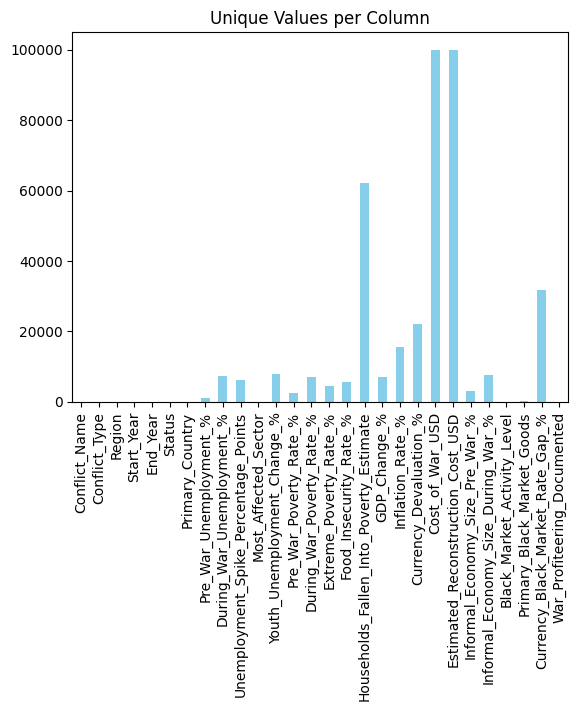

In [66]:
df.nunique().plot(kind='bar', color='skyblue')
plt.title("Unique Values per Column")
plt.show()

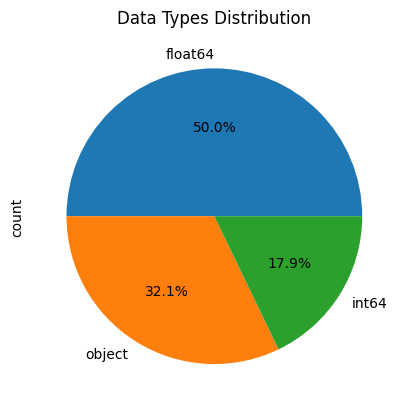

In [67]:
df.dtypes.value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Data Types Distribution")
plt.show()

In [45]:
df['GDP_Change_%'].min()



-85.0

In [46]:
df['GDP_Change_%'].max()


-5.0

In [47]:
df['GDP_Change_%'].mean()

np.float64(-31.614770299999996)

In [48]:
df['Inflation_Rate_%'].describe()



,Inflation_Rate_%
count,100000.000000
mean,69.945965
std,35.045196
min,0.030000
25%,42.710000
50%,69.290000
75%,94.800000
max,295.560000


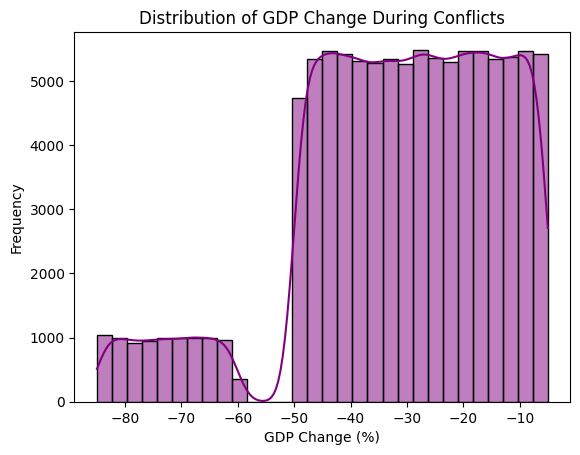

In [68]:
#GDP Collapse Distribution
sns.histplot(df['GDP_Change_%'], bins=30, kde=True, color='purple')
plt.title("Distribution of GDP Change During Conflicts")
plt.xlabel("GDP Change (%)")
plt.ylabel("Frequency")
plt.show()





In [50]:
peak1 = df[(df['GDP_Change_%'] >= -50) & (df['GDP_Change_%'] <= -5)]
print("Peak 1 count:", len(peak1))
print("Peak 1 average GDP change:", peak1['GDP_Change_%'].mean())

Peak 1 count: 90803
Peak 1 average GDP change: -27.46852218539035


In [51]:
peak2 = df[(df['GDP_Change_%'] >= -85) & (df['GDP_Change_%'] <= -55)]
print("Peak 2 count:", len(peak2))
print("Peak 2 average GDP change:", peak2['GDP_Change_%'].mean())

Peak 2 count: 9197
Peak 2 average GDP change: -72.55113732738937


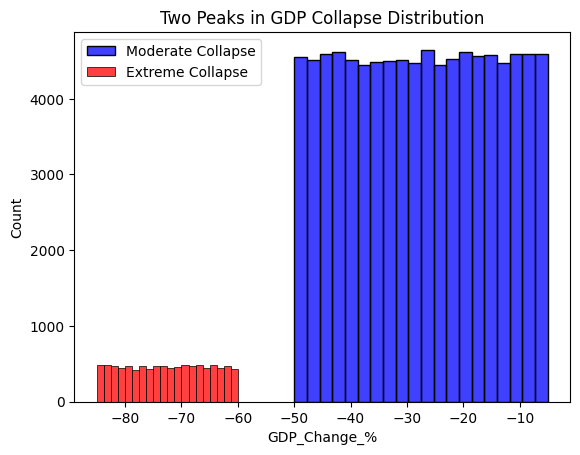

In [52]:
sns.histplot(peak1['GDP_Change_%'], bins=20, color='blue', label='Moderate Collapse')
sns.histplot(peak2['GDP_Change_%'], bins=20, color='red', label='Extreme Collapse')
plt.legend()
plt.title("Two Peaks in GDP Collapse Distribution")
plt.show()


In [53]:
peak1 = df[(df['GDP_Change_%'] >= -50) & (df['GDP_Change_%'] <= -5)]
peak1_conflicts = peak1['Conflict_Name'].unique()
print("Wars in Peak 1:", peak1_conflicts)



Wars in Peak 1: ['WWII (Japan)' 'Syrian Civil War' 'WWII (Germany)' 'Afghanistan War'
 'Russia-Ukraine War' 'DRC Conflict' 'Yemen Civil War' 'Israel-Iran War'
 'Tigray Conflict' 'Iraq War']


In [54]:
peak2 = df[(df['GDP_Change_%'] >= -85) & (df['GDP_Change_%'] <= -55)]
peak2_conflicts = peak2['Conflict_Name'].unique()
print("Wars in Peak 2:", peak2_conflicts)


Wars in Peak 2: ['Israel-Hamas War']


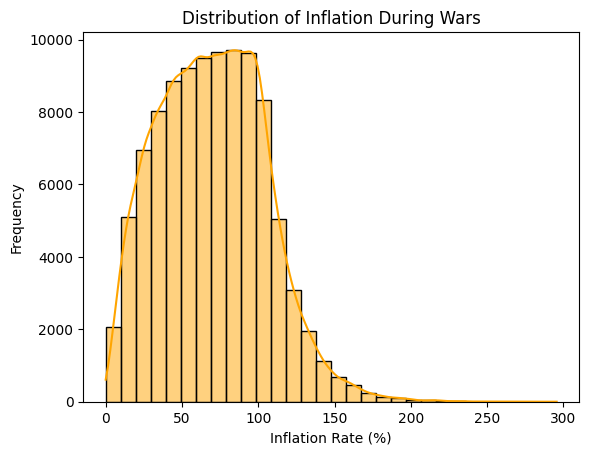

In [71]:
#Inflation Distribution
sns.histplot(df['Inflation_Rate_%'], bins=30, kde=True, color='orange')
plt.title("Distribution of Inflation During Wars")
plt.xlabel("Inflation Rate (%)")
plt.ylabel("Frequency")
plt.show()

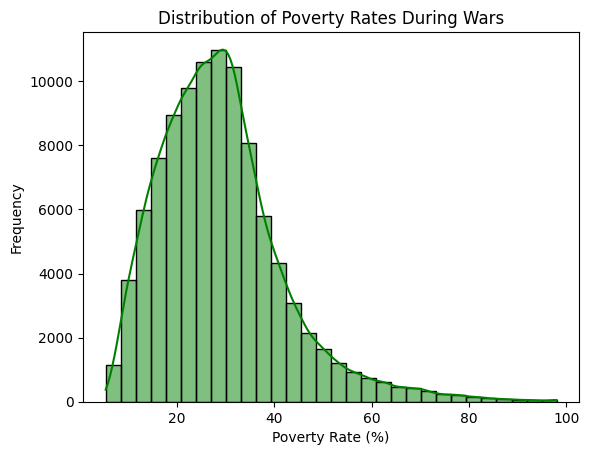

In [72]:
#Poverty Distribution
sns.histplot(df['During_War_Poverty_Rate_%'], bins=30, kde=True, color='green')
plt.title("Distribution of Poverty Rates During Wars")
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Frequency")
plt.show()


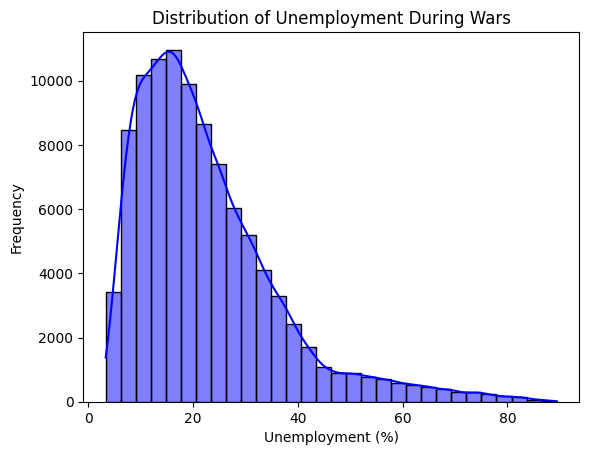

In [74]:
#Unemployment Distribution
sns.histplot(df['During_War_Unemployment_%'], bins=30, kde=True, color='blue')
plt.title("Distribution of Unemployment During Wars")
plt.xlabel("Unemployment (%)")
plt.ylabel("Frequency")
plt.show()


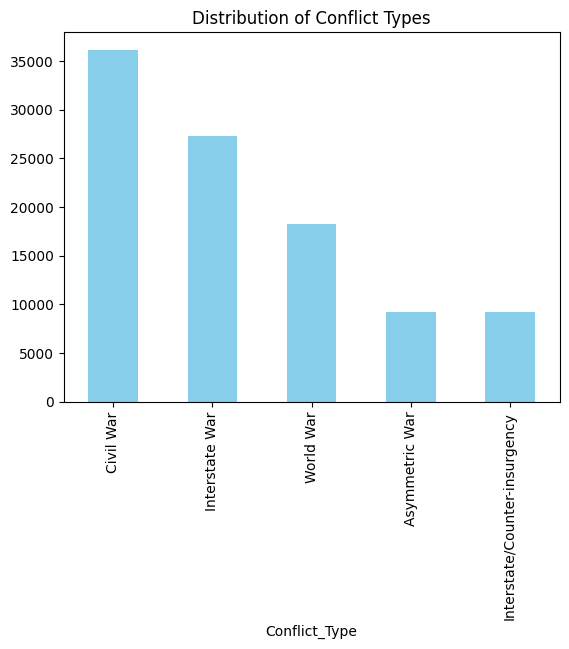

In [77]:
#Categorical Distributions
df['Conflict_Type'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Distribution of Conflict Types")
plt.show()




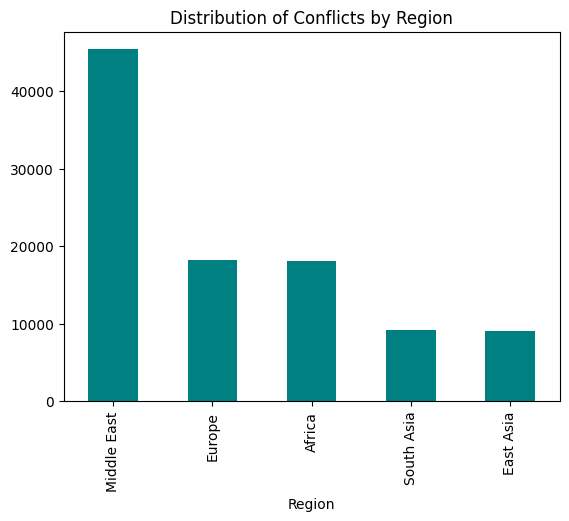

In [78]:
df['Region'].value_counts().plot(kind='bar', color='teal')
plt.title("Distribution of Conflicts by Region")
plt.show()

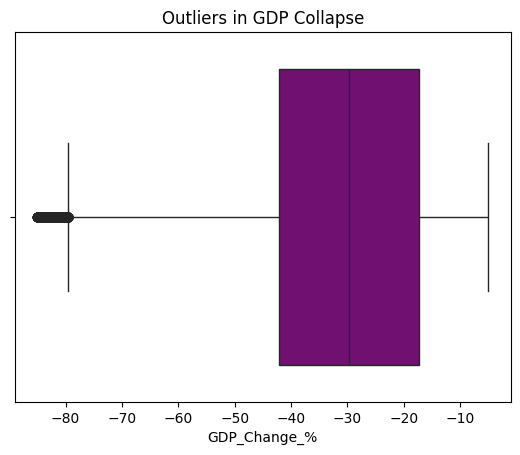

          Conflict_Name  GDP_Change_%
1      Israel-Hamas War        -64.99
7      Israel-Hamas War        -68.44
42     Israel-Hamas War        -65.81
78     Israel-Hamas War        -81.77
79     Israel-Hamas War        -64.24
...                 ...           ...
99944  Israel-Hamas War        -71.64
99953  Israel-Hamas War        -82.72
99972  Israel-Hamas War        -72.04
99989  Israel-Hamas War        -60.72
99998  Israel-Hamas War        -66.86

[9197 rows x 2 columns]


In [79]:
#GDP Collapse Outliers
sns.boxplot(x=df['GDP_Change_%'], color='purple')
plt.title("Outliers in GDP Collapse")
plt.show()

# Extract wars with catastrophic GDP collapse
outliers_gdp = df[df['GDP_Change_%'] < -55]
print(outliers_gdp[['Conflict_Name','GDP_Change_%']])


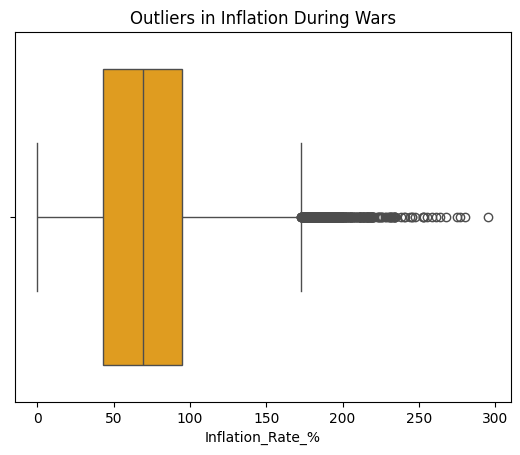

Empty DataFrame
Columns: [Conflict_Name, Inflation_Rate_%]
Index: []


In [80]:
#Inflation Outliers
sns.boxplot(x=df['Inflation_Rate_%'], color='orange')
plt.title("Outliers in Inflation During Wars")
plt.show()

# Extract hyperinflation cases
outliers_inflation = df[df['Inflation_Rate_%'] > 1000]
print(outliers_inflation[['Conflict_Name','Inflation_Rate_%']])


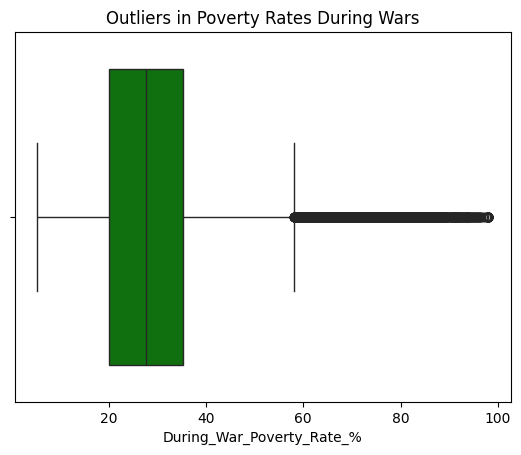

          Conflict_Name  During_War_Poverty_Rate_%
63     Syrian Civil War                      87.41
67      Yemen Civil War                      64.22
77     Syrian Civil War                      60.03
78     Israel-Hamas War                      68.56
127    Israel-Hamas War                      79.16
...                 ...                        ...
99874  Syrian Civil War                      69.07
99879   Yemen Civil War                      84.85
99901  Syrian Civil War                      70.93
99923  Israel-Hamas War                      70.68
99947  Syrian Civil War                      73.92

[2964 rows x 2 columns]


In [81]:
#Poverty Outliers
sns.boxplot(x=df['During_War_Poverty_Rate_%'], color='green')
plt.title("Outliers in Poverty Rates During Wars")
plt.show()

# Extract extreme poverty cases
outliers_poverty = df[df['During_War_Poverty_Rate_%'] > 60]
print(outliers_poverty[['Conflict_Name','During_War_Poverty_Rate_%']])


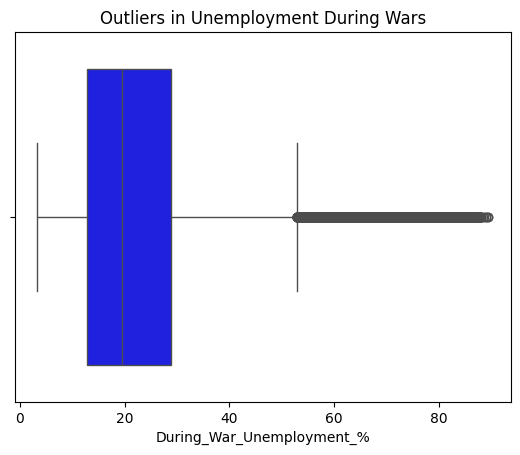

          Conflict_Name  During_War_Unemployment_%
7      Israel-Hamas War                      42.10
21         DRC Conflict                      40.99
28      Afghanistan War                      40.21
63     Syrian Civil War                      84.47
66     Syrian Civil War                      47.81
...                 ...                        ...
99944  Israel-Hamas War                      55.84
99947  Syrian Civil War                      77.46
99952   Yemen Civil War                      50.63
99968   Yemen Civil War                      47.37
99992  Syrian Civil War                      60.97

[9728 rows x 2 columns]


In [82]:
#Unemployment Outliers
sns.boxplot(x=df['During_War_Unemployment_%'], color='blue')
plt.title("Outliers in Unemployment During Wars")
plt.show()

# Extract extreme unemployment cases
outliers_unemployment = df[df['During_War_Unemployment_%'] > 40]
print(outliers_unemployment[['Conflict_Name','During_War_Unemployment_%']])


In [83]:
#Compare by Conflict Type
df.groupby('Conflict_Type')['GDP_Change_%'].mean().sort_values()


,GDP_Change_%
Conflict_Type,
Asymmetric War,-72.551137
Interstate/Counter-insurgency,-27.621735
Civil War,-27.462488
Interstate War,-27.459210
World War,-27.417440


In [84]:
#Compare by Region
df.groupby('Region')['Inflation_Rate_%'].mean().sort_values()


,Inflation_Rate_%
Region,
South Asia,69.867762
Africa,69.881182
Europe,69.921274
East Asia,69.957683
Middle East,69.995181


In [88]:
#Moderate vs Catastrophic Collapse
def collapse_category(x):
    if -50 <= x <= -5:
        return "Moderate Collapse"
    elif -85 <= x <= -55:
        return "Extreme Collapse"
    else:
        return "Other"

df['Collapse_Category'] = df['GDP_Change_%'].apply(collapse_category)
df.groupby('Collapse_Category')[['Inflation_Rate_%','During_War_Poverty_Rate_%']].mean()


,Inflation_Rate_%,During_War_Poverty_Rate_%
Collapse_Category,,
Extreme Collapse,69.755312,38.465313
Moderate Collapse,69.965275,28.126307


In [90]:
#Cost Comparisons
(df.groupby('Conflict_Type')['Reconstruction_vs_WarCost'].mean() * 100).round(1)


,Reconstruction_vs_WarCost
Conflict_Type,
Asymmetric War,274.9
Civil War,275.0
Interstate War,275.1
Interstate/Counter-insurgency,274.0
World War,275.2


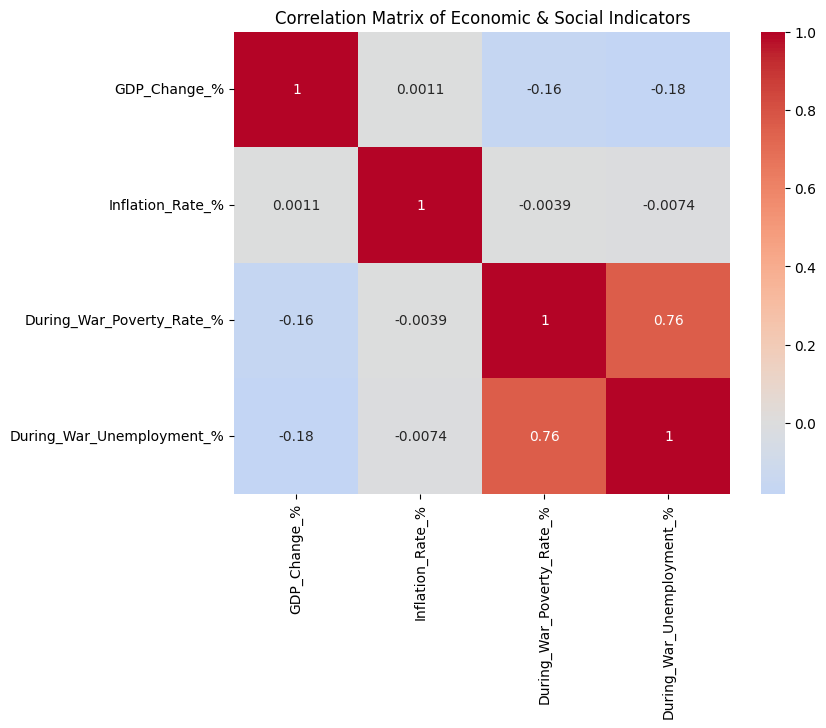

In [92]:
#Correlation Matrix
corr = df[['GDP_Change_%','Inflation_Rate_%','During_War_Poverty_Rate_%','During_War_Unemployment_%']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix of Economic & Social Indicators")
plt.show()


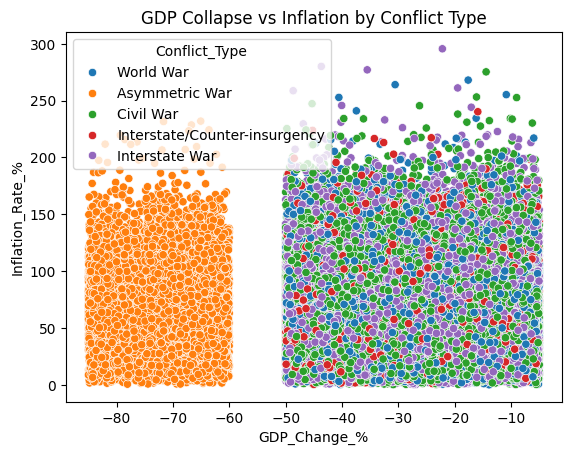

In [93]:
#Scatterplot: GDP vs Inflation
sns.scatterplot(x='GDP_Change_%', y='Inflation_Rate_%', data=df, hue='Conflict_Type')
plt.title("GDP Collapse vs Inflation by Conflict Type")
plt.show()


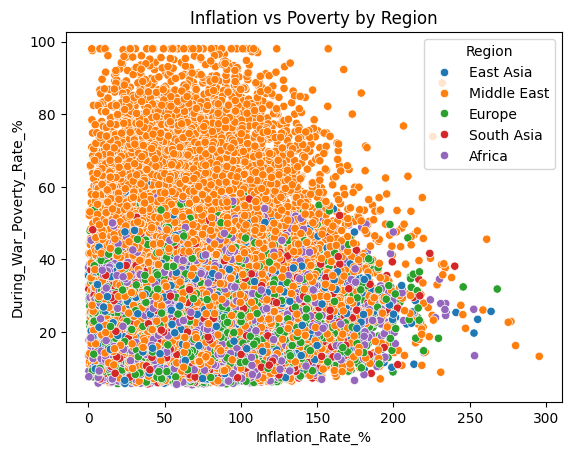

In [94]:
#Scatterplot: Inflation vs Poverty
sns.scatterplot(x='Inflation_Rate_%', y='During_War_Poverty_Rate_%', data=df, hue='Region')
plt.title("Inflation vs Poverty by Region")
plt.show()


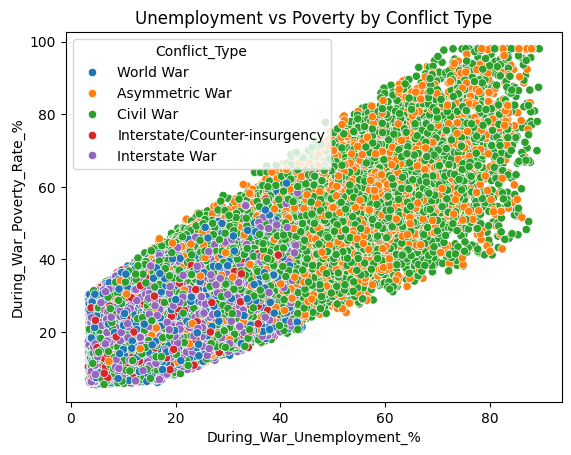

In [95]:
#Scatterplot: Unemployment vs Poverty
sns.scatterplot(x='During_War_Unemployment_%', y='During_War_Poverty_Rate_%', data=df, hue='Conflict_Type')
plt.title("Unemployment vs Poverty by Conflict Type")
plt.show()
